<a href="https://colab.research.google.com/github/omrizt17-art/SustainedAttension_EC_EO_ACW_Preprocessed/blob/main/SustainedAttentionTask_ACW_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#Loading files
import pandas as pd
import os
!pip install pingouin
RESULTS_DIR = "/content/drive/MyDrive/tiw_project_EO_EC/acw_results"

df_ec = pd.read_csv(os.path.join(RESULTS_DIR, "ACW_ALL_SUBJECTS_EC.csv"))
df_eo = pd.read_csv(os.path.join(RESULTS_DIR, "ACW_ALL_SUBJECTS_EO.csv"))

df = pd.concat([df_ec, df_eo], ignore_index=True)

print(df.shape)
df.head()

(2464, 6)


,Subject,ROI,Cluster,ACW_s,ACW_grand_mean_s,Condition
0,sub-001,bankssts-lh,1,0.016082,0.020823,EC
1,sub-001,bankssts-rh,1,0.018825,0.020823,EC
2,sub-001,caudalmiddlefrontal-lh,3,0.016747,0.020823,EC
3,sub-001,caudalmiddlefrontal-rh,3,0.020819,0.020823,EC
4,sub-001,cuneus-lh,1,0.021983,0.020823,EC


In [5]:
from scipy.stats import ttest_rel

# one value per subject per condition
df_global = df.groupby(["Subject", "Condition"])["ACW_grand_mean_s"].mean().unstack()

print(df_global.head())

t_stat, p_val = ttest_rel(df_global["EC"], df_global["EO"])

print("\n=== GLOBAL COMPARISON ===")
print("t =", t_stat)
print("p =", p_val)

Condition        EC        EO
Subject                      
sub-001    0.020823  0.020703
sub-002    0.064025  0.056304
sub-004    0.040038  0.021190
sub-005    0.056946  0.048850
sub-006    0.056915  0.055621

=== GLOBAL COMPARISON ===
t = 2.6958207780330903
p = 0.011938351526872145


In [7]:
!pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 5.1 MB/s eta 0:00:00


In [13]:
from collections import defaultdict

# ---- Define labels for clusters ----
cluster_labels = {
    1: "Visual / Occipito-temporal (sensory)",
    2: "Parietal / Association",
    3: "Frontal / Executive",
    4: "Insula / Salience"
}

# ---- Build mapping ----
cluster_map = defaultdict(set)

for _, row in df.iterrows():
    cluster_map[row["Cluster"]].add(row["ROI"])

# ---- Print nicely ----
for c in sorted(cluster_map):
    label = cluster_labels.get(c, "Unknown")
    print(f"\nCluster {c} — {label}:")

    for roi in sorted(cluster_map[c]):
        print("  ", roi)


Cluster 1 — Visual / Occipito-temporal (sensory):
   bankssts-lh
   bankssts-rh
   cuneus-lh
   cuneus-rh
   fusiform-lh
   fusiform-rh
   inferiortemporal-lh
   inferiortemporal-rh
   lateraloccipital-lh
   lateraloccipital-rh
   lingual-lh
   lingual-rh
   middletemporal-lh
   middletemporal-rh
   pericalcarine-lh
   pericalcarine-rh

Cluster 2 — Parietal / Association:
   inferiorparietal-lh
   inferiorparietal-rh
   posteriorcingulate-lh
   posteriorcingulate-rh
   precuneus-lh
   precuneus-rh
   superiorparietal-lh
   superiorparietal-rh
   supramarginal-lh
   supramarginal-rh

Cluster 3 — Frontal / Executive:
   caudalmiddlefrontal-lh
   caudalmiddlefrontal-rh
   frontalpole-lh
   frontalpole-rh
   parsopercularis-lh
   parsopercularis-rh
   parsorbitalis-lh
   parsorbitalis-rh
   parstriangularis-lh
   parstriangularis-rh
   precentral-lh
   precentral-rh
   rostralmiddlefrontal-lh
   rostralmiddlefrontal-rh
   superiorfrontal-lh
   superiorfrontal-rh

Cluster 4 — Insula / Sali

In [8]:
import pingouin as pg

df_cluster = df.copy()

anova = pg.rm_anova(
    data=df_cluster,
    dv="ACW_s",
    within=["Condition", "Cluster"],
    subject="Subject",
    detailed=True
)

print("\n=== CLUSTER ANOVA ===")
print(anova)


=== CLUSTER ANOVA ===
                Source        SS  ddof1  ddof2        MS          F  \
0            Condition  0.000788      1     27  0.000788   5.576574   
1              Cluster  0.017355      3     81  0.005785  30.706528   
2  Condition * Cluster  0.005815      3     81  0.001938  37.673650   

          p_unc     p_GG_corr       ng2       eps  
0  2.567311e-02  2.567311e-02  0.013513  1.000000  
1  2.335216e-13  1.919345e-10  0.231880  0.739006  
2  2.411589e-15  2.114371e-08  0.091852  0.472112  


In [20]:
pg.pairwise_tests(
    data=df,
    dv="ACW_s",
    within="Condition",
    subject="Subject",
    between="Cluster",
    padjust="fdr_bh"
)

,Contrast,Condition,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,hedges
0,Condition,-,EC,EO,True,True,2.361477,27.0,two-sided,0.025673,NaN,NaN,2.102,0.278554
1,Cluster,-,1,2,False,True,-2.941013,54.0,two-sided,0.004809,0.007214,fdr_bh,8.534,-0.775051
2,Cluster,-,1,3,False,True,-3.916331,54.0,two-sided,0.000255,0.000509,fdr_bh,98.881,-1.032079
3,Cluster,-,1,4,False,True,2.030637,54.0,two-sided,0.047228,0.056674,fdr_bh,1.459,0.535138
4,Cluster,-,2,3,False,True,-1.138673,54.0,two-sided,0.259866,0.259866,fdr_bh,0.462,-0.300077
5,Cluster,-,2,4,False,True,4.359383,54.0,two-sided,0.000059,0.000177,fdr_bh,350.568,1.148837
6,Cluster,-,3,4,False,True,5.157460,54.0,two-sided,0.000004,0.000022,fdr_bh,4109.644,1.359156
7,Condition * Cluster,EC,1,2,False,True,-2.600740,54.0,two-sided,0.011976,0.015968,fdr_bh,4.132,-0.685378
8,Condition * Cluster,EC,1,3,False,True,-5.398363,54.0,two-sided,0.000002,0.000006,fdr_bh,8959.988,-1.422642
9,Condition * Cluster,EC,1,4,False,True,0.515113,54.0,two-sided,0.608576,0.608576,fdr_bh,0.302,0.135749


In [21]:
def stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

posthoc["sig"] = posthoc["p_corr"].apply(stars)

posthoc[["A", "B", "T", "p_corr", "sig"]]

,A,B,T,p_corr,sig
0,EC,EO,2.361477,NaN,ns
1,1,2,-2.941013,0.007214,**
2,1,3,-3.916331,0.000509,***
3,1,4,2.030637,0.056674,ns
4,2,3,-1.138673,0.259866,ns
5,2,4,4.359383,0.000177,***
6,3,4,5.157460,0.000022,***
7,1,2,-2.600740,0.015968,*
8,1,3,-5.398363,0.000006,***
9,1,4,0.515113,0.608576,ns


In [22]:
def direction(row):
    a, b, t = row["A"], row["B"], row["T"]
    return f"{a} > {b}" if t > 0 else f"{b} > {a}"

# Use original posthoc here, not the formatted one
ph2 = posthoc.copy()

def stars_raw(p):
    if pd.isna(p):
        return ""
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

ph2["sig"] = ph2["p_corr"].apply(stars_raw)
ph2["direction"] = ph2.apply(direction, axis=1)

# Overall cluster differences
sig_overall = ph2[(ph2["Contrast"] == "Cluster") & (ph2["sig"] != "ns")]

print("\n=== OVERALL SIGNIFICANT CLUSTER DIFFERENCES ===")
for _, row in sig_overall.iterrows():
    print(f"Cluster {row['direction']}   |   p_corr={row['p_corr']:.4g}   |   {row['sig']}")

# EC-only
sig_ec = ph2[
    (ph2["Contrast"] == "Condition * Cluster") &
    (ph2["Condition"] == "EC") &
    (ph2["sig"] != "ns")
]

print("\n=== SIGNIFICANT DIFFERENCES IN EC ===")
for _, row in sig_ec.iterrows():
    print(f"EC: Cluster {row['direction']}   |   p_corr={row['p_corr']:.4g}   |   {row['sig']}")

# EO-only
sig_eo = ph2[
    (ph2["Contrast"] == "Condition * Cluster") &
    (ph2["Condition"] == "EO") &
    (ph2["sig"] != "ns")
]

print("\n=== SIGNIFICANT DIFFERENCES IN EO ===")
for _, row in sig_eo.iterrows():
    print(f"EO: Cluster {row['direction']}   |   p_corr={row['p_corr']:.4g}   |   {row['sig']}")


=== OVERALL SIGNIFICANT CLUSTER DIFFERENCES ===
Cluster 2 > 1   |   p_corr=0.007214   |   **
Cluster 3 > 1   |   p_corr=0.0005091   |   ***
Cluster 2 > 4   |   p_corr=0.0001768   |   ***
Cluster 3 > 4   |   p_corr=2.196e-05   |   ***

=== SIGNIFICANT DIFFERENCES IN EC ===
EC: Cluster 2 > 1   |   p_corr=0.01597   |   *
EC: Cluster 3 > 1   |   p_corr=6.159e-06   |   ***
EC: Cluster 3 > 2   |   p_corr=0.003984   |   **
EC: Cluster 2 > 4   |   p_corr=0.01096   |   *
EC: Cluster 3 > 4   |   p_corr=6.159e-06   |   ***

=== SIGNIFICANT DIFFERENCES IN EO ===
EO: Cluster 2 > 1   |   p_corr=0.00651   |   **
EO: Cluster 1 > 4   |   p_corr=0.003984   |   **
EO: Cluster 2 > 4   |   p_corr=6.159e-06   |   ***
EO: Cluster 3 > 4   |   p_corr=0.00138   |   **


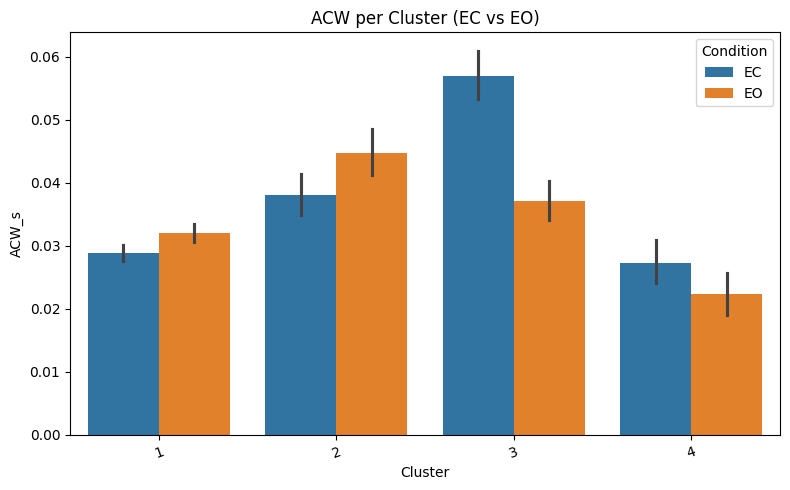

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(
    data=df_cluster,
    x="Cluster",
    y="ACW_s",
    hue="Condition",
    estimator="mean"
)

plt.title("ACW per Cluster (EC vs EO)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()